# Data Evaluation: User Study

## 0. Setup

In [28]:
import pandas as pd
import matplotlib as mpl
%matplotlib inline

data_df = pd.read_csv('../eval-toolchain/eval-data.csv')
data_df

,participant,p_id,date,group,s_issues_miro,s_issues_pixie,s_issues_correct_miro,s_issues_correct_pixie,p_answered_miro,p_answered_pixie,p_answered_correct_miro,p_answered_correct_pixie
0,2,PA40344,2026-06-29,AP,5.0,3.0,NaN,NaN,6.0,6.0,NaN,NaN
1,5,MA7125,2026-06-30,AM,2.0,3.0,NaN,NaN,4.0,3.0,NaN,NaN
2,21,MA26593,2026-07-07,AM,1.0,0.0,NaN,NaN,3.0,4.0,NaN,NaN
3,20,PB3394,2026-07-06,BP,2.0,0.0,NaN,NaN,6.0,6.0,NaN,NaN
4,14,PA4076,2026-07-02,AP,2.0,5.0,NaN,NaN,6.0,4.0,NaN,NaN
5,16,PB46220,2026-07-02,BP,4.0,2.0,NaN,NaN,5.0,3.0,NaN,NaN
6,6,PA45003,2026-06-30,AP,2.0,1.0,NaN,NaN,3.0,4.0,NaN,NaN
7,4,PB54700,2026-06-30,BP,3.0,2.0,NaN,NaN,6.0,3.0,NaN,NaN
8,7,MB24145,2026-06-30,BM,3.0,2.0,NaN,NaN,1.0,4.0,NaN,NaN
9,15,MB10509,2026-07-02,BM,3.0,1.0,NaN,NaN,3.0,5.0,NaN,NaN


## 1. Data Exploration

### Total Numbers of Issues/Answered Questions

includes incorrect answers

In [29]:
total_counts_data_cols = [
    's_issues_miro',
    's_issues_pixie',
    'p_answered_miro',
    'p_answered_pixie',
]
total_counts_solvability = [
    's_issues_miro',
    's_issues_pixie',

]
total_counts_pacing = [
    'p_answered_miro',
    'p_answered_pixie',
]
#num_data_df = data_df[num_data_cols]
#num_data_df.index = data_df['p_id']
#plot = num_data_df.plot.pie(subplots=True, figsize=(5, 5))

#### Distribution of Total Number of Identified Issues Across Participants By Tool

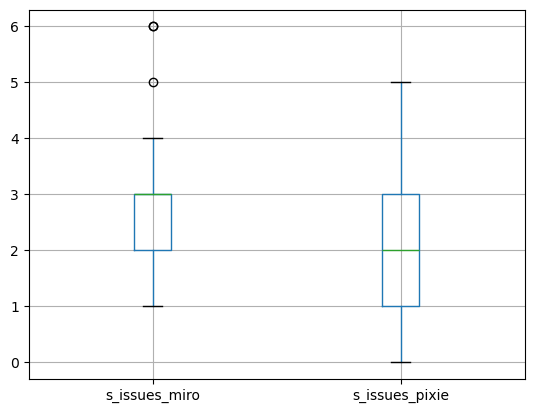

In [30]:
total_solvability_boxplot = data_df.boxplot(column=total_counts_solvability)

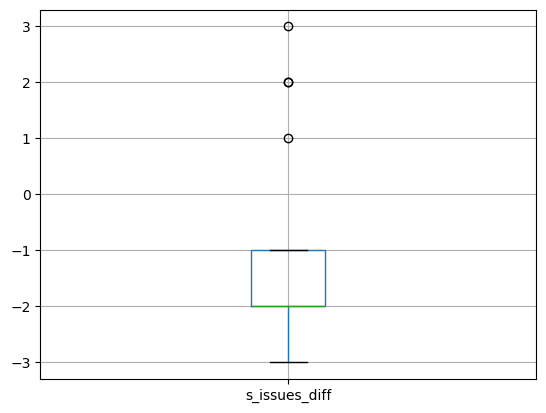

In [31]:
data_df['s_issues_diff'] = data_df['s_issues_pixie'] - data_df['s_issues_miro']
solvability_diff = data_df.boxplot(column=['s_issues_diff'])

#### Distribution of Total Number of Identified Issues Across Participants By Tool And Variant

In [32]:
# total_solvability_boxplot = data_df.boxplot(column=total_counts_solvability)

### Timeseries

In [33]:
timeseries_data_df = pd.read_csv('../eval-toolchain/time_series/all.csv')
timeseries_data_df

,p_id,group,task,map,timestamp,tag,note,timedelta
0,PA40344,AP,solvability_pixie,LA_3,01:27:30,STA,NaN,0
1,PA40344,AP,solvability_pixie,LA_3,01:27:44,OBS,pathfinding start-room after boss,14
2,PA40344,AP,solvability_pixie,LA_3,01:28:08,vb,ath blocked to boss,38
3,PA40344,AP,solvability_pixie,LA_3,01:28:45,OBS,successive pathfinding,75
4,PA40344,AP,solvability_pixie,LA_3,01:28:56,vb,oftlock 14,86
...,...,...,...,...,...,...,...,...
731,MB67500,BM,pacing_miro,LA_2,15:39:55,Q2A,section A faster on average,250
732,MB67500,BM,pacing_miro,LA_2,15:40:25,Q5A,"increases: 16-18, 21-2 to 21-3",280
733,MB67500,BM,pacing_miro,LA_2,15:40:45,rem,"rk: need boss key, but same result",300
734,MB67500,BM,pacing_miro,LA_2,15:41:07,Q4A,miniboss ~~21-3~~ 15,322


#### Timeseries: Issues

In [34]:
issues_data_df = timeseries_data_df[timeseries_data_df['tag'] == 'ISS']
issues_data_df

,p_id,group,task,map,timestamp,tag,note,timedelta
31,MA7125,AM,solvability_pixie,LA_4,11:32:16,ISS,missing key between 31 and Boss,78
32,MA7125,AM,solvability_pixie,LA_4,11:33:16,ISS,12 not reachable,138
35,MA7125,AM,solvability_pixie,LA_4,11:36:42,ISS,one-directional path 12-11,344
39,MA7125,AM,solvability_miro,LA_3,11:27:20,ISS,cannot got further than marked path,231
40,MA7125,AM,solvability_miro,LA_3,11:27:49,ISS,one-directional path 12-15,260
...,...,...,...,...,...,...,...,...
711,MB67500,BM,solvability_miro,LA_4,15:22:51,ISS,cant get to 11 without new ability,30
712,MB67500,BM,solvability_miro,LA_4,15:23:08,ISS,can't get to 39,47
713,MB67500,BM,solvability_miro,LA_4,15:23:42,ISS,missing key 26-27,81
714,MB67500,BM,solvability_miro,LA_4,15:25:05,ISS,16-37 blocked bc no bombs,164


In [35]:
first_issues_df = issues_data_df.loc[issues_data_df.groupby(['p_id', 'task']).timedelta.idxmin()]
first_issues_df

,p_id,group,task,map,timestamp,tag,note,timedelta
603,MA12534,AM,solvability_miro,LA_3,11:21:21,ISS,"hard lock 6, pretty confident",159
69,MA26593,AM,solvability_miro,LA_3,11:23:57,ISS,softlock in 4 if ability check not passed,99
452,MA34230,AM,solvability_miro,LA_3,17:26:49,ISS,if bomb used on 13 - 14: softlock in 14,130
446,MA34230,AM,solvability_pixie,LA_4,17:36:46,ISS,6-12 not unlockable,270
39,MA7125,AM,solvability_miro,LA_3,11:27:20,ISS,cannot got further than marked path,231
31,MA7125,AM,solvability_pixie,LA_4,11:32:16,ISS,missing key between 31 and Boss,78
373,MA95137,AM,solvability_miro,LA_3,15:26:14,ISS,hardlocked in 6,39
637,MA95935,AM,solvability_miro,LA_3,16:26:50,ISS,not enough bombs 22-23,156
304,MB10509,BM,solvability_pixie,LA_3,13:34:03,ISS,hardlock in 6,40
277,MB24145,BM,solvability_miro,LA_4,01:23:15,ISS,can't unlock boss lock 31-39,114


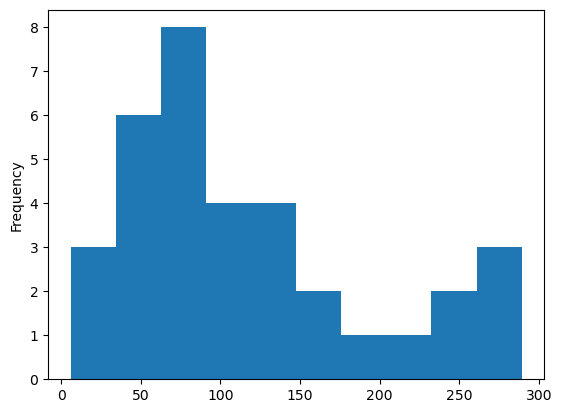

In [36]:

time_to_first_issue_hist = first_issues_df['timedelta'].plot.hist()
# time_to_first_issue_hist = first_issues_df.timedelta.plot.hist(groupby='task')
# time_to_first_issue_hist = first_issues_df.plot.hist('timadelta', by='task')

##### Distribution of First Issue Found Events Across Participants By Task

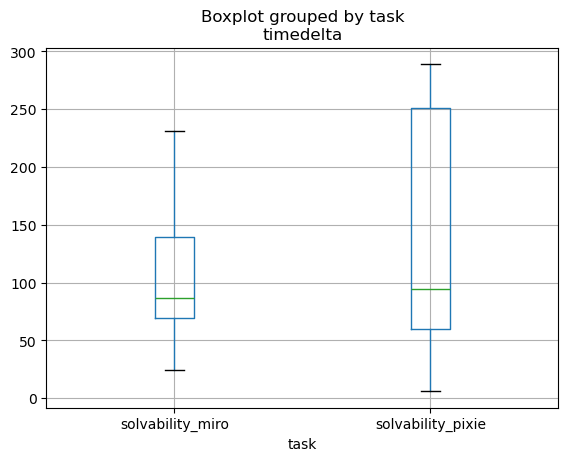

In [37]:
time_to_first_issue_box = first_issues_df.boxplot(by='task', column='timedelta')

##### Time To First Issue By Tool And Map

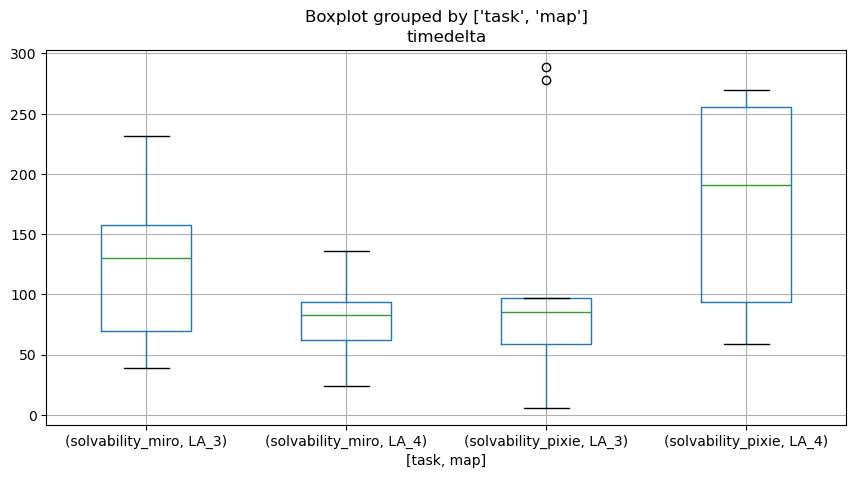

In [38]:
time_to_first_issue_box_task = first_issues_df.boxplot(by=['task', 'map'], column='timedelta', figsize=(10, 5))

##### Distribution of Issue Found Events Across Time

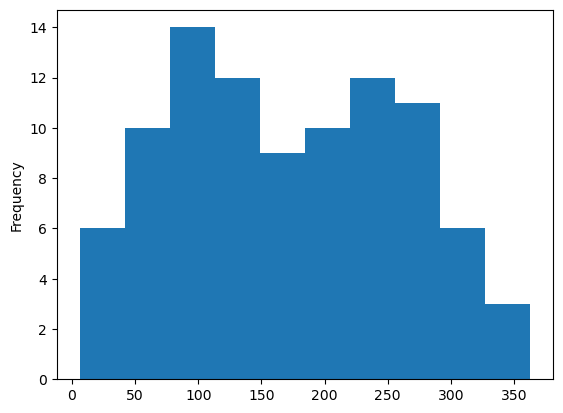

In [39]:
ax2 = issues_data_df['timedelta'].plot.hist()